<a href="https://colab.research.google.com/github/ashrafsohail42003/Prediction-of-Product-Sales/blob/main/Data_Cleaning_%26_Exploration(Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data and import library


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:

fname = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df = pd.read_csv(fname)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Data Cleaning

In [16]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n')
print('Data types for each column:')
print(df.dtypes)

The dataset has 8523 rows and 12 columns.

Data types for each column:
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object


## Handle Duplicates



In [17]:
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows is: {duplicate_count}')

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')
else:
    print('No duplicate rows to remove.')

print(f'The updated dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

Number of duplicate rows is: 0
No duplicate rows to remove.
The updated dataset has 8523 rows and 12 columns.


## Missing Value Treatment

In [18]:
df = df.copy()

print('Missing values before treatment:')
print(df.isna().sum())

# Handle Item_Weight if it exists in the dataset
if 'Item_Weight' in df.columns:
    mean_weight = df['Item_Weight'].mean()
    df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

# Handle Outlet_Size if it exists in the dataset
if 'Outlet_Size' in df.columns:
    df['Outlet_Size'] = df['Outlet_Size'].fillna('Missing')

print('\nMissing values after treatment:')
print(df.isna().sum())

Missing values before treatment:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Missing values after treatment:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


## Category Standardization


In [19]:
# Check unique values in Item_Fat_Content before standardization
print('Value counts before standardization:')
print(df['Item_Fat_Content'].value_counts())

# Standardize labels using a mapping dictionary
fat_content_map = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
}

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_content_map)

# Verify the standardization
print('\nValue counts after standardization:')
print(df['Item_Fat_Content'].value_counts())

# Optional: Check other categorical columns for consistency
print('\nUnique values in Item_Type:')
print(df['Item_Type'].unique())

print('\nUnique values in Outlet_Type:')
print(df['Outlet_Type'].unique())

Value counts before standardization:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Value counts after standardization:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Unique values in Item_Type:
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Unique values in Outlet_Type:
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


## Numerical Analysis



In [20]:
numeric_cols = df.select_dtypes(include=['number'])

summary_stats = numeric_cols.agg(['min', 'max', 'mean']).transpose()

print('Summary Statistics for Numerical Columns:')
summary_stats

Summary Statistics for Numerical Columns:


,min,max,mean
Item_Weight,4.555,21.350000,12.857645
Item_Visibility,0.000,0.328391,0.066132
Item_MRP,31.290,266.888400,140.992782
Outlet_Establishment_Year,1985.000,2009.000000,1997.831867
Item_Outlet_Sales,33.290,13086.964800,2181.288914




```
# This is formatted as code
```

# Histograms

In [27]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

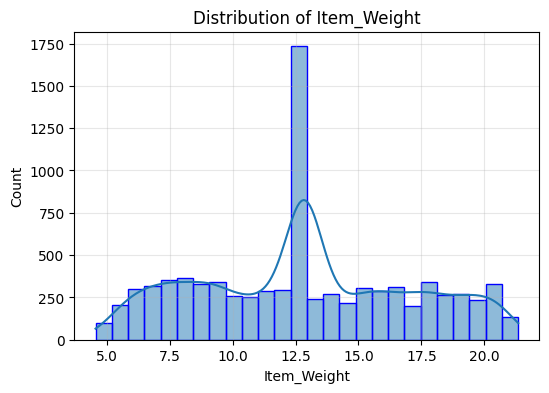

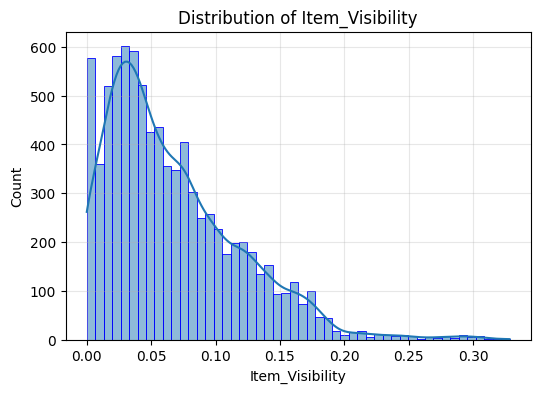

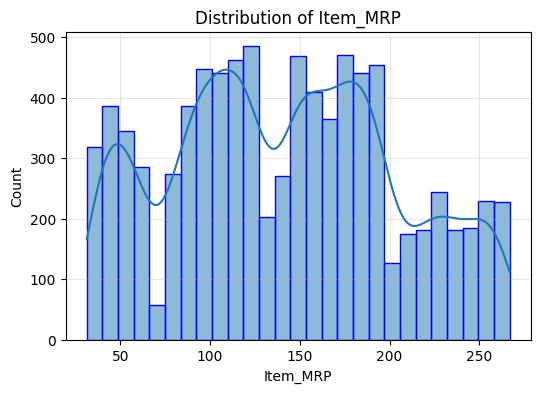

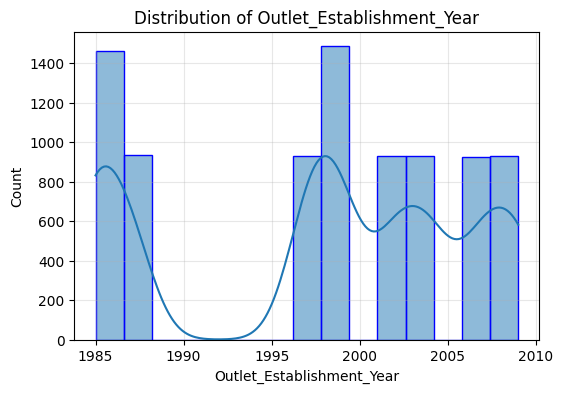

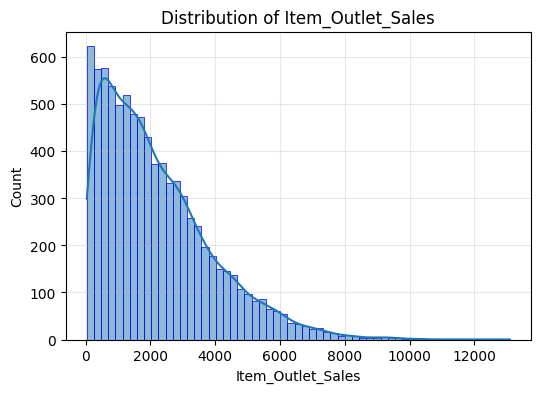

In [35]:
for c in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=c, bins='auto', edgecolor='blue', kde=True)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Count')
    plt.grid(alpha=0.3)


#Boxplots


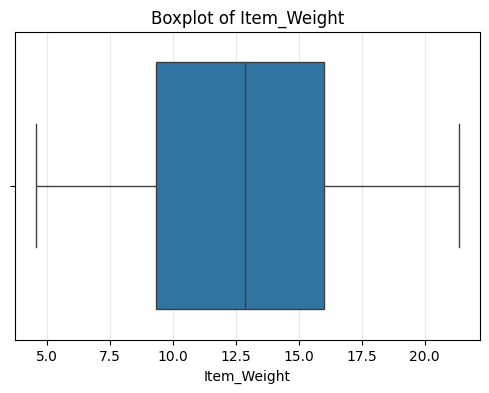

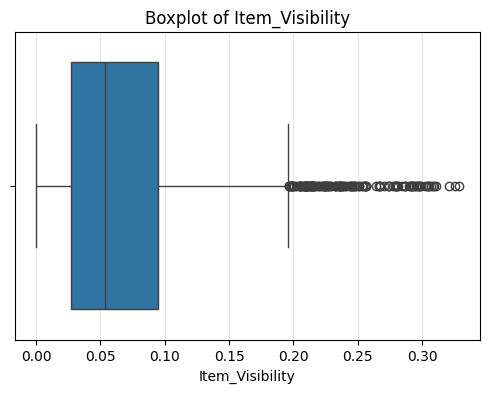

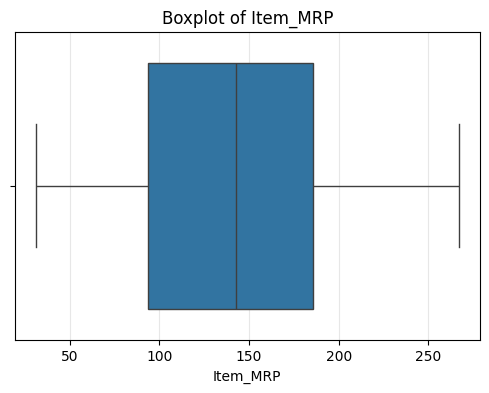

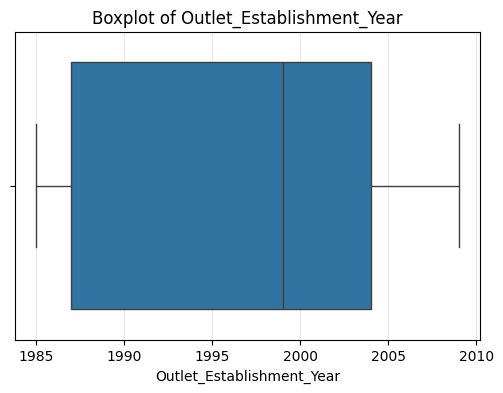

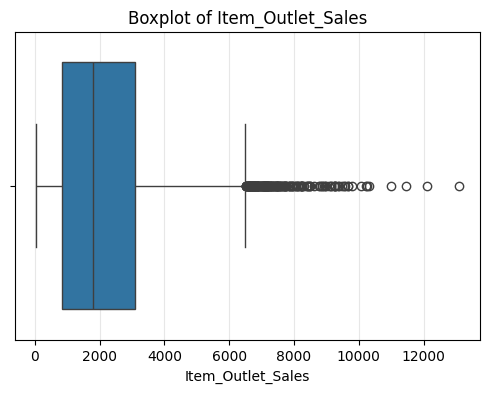

In [34]:
for c in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=c)
    plt.title(f'Boxplot of {c}')
    plt.xlabel(c)
    plt.grid(axis='x', alpha=0.3)


# Countplots

In [42]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

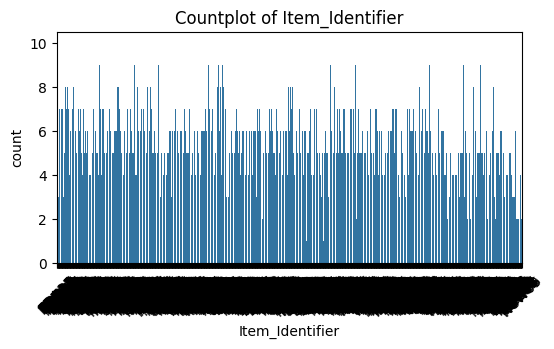

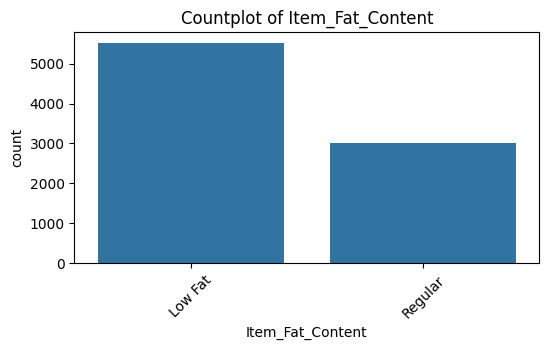

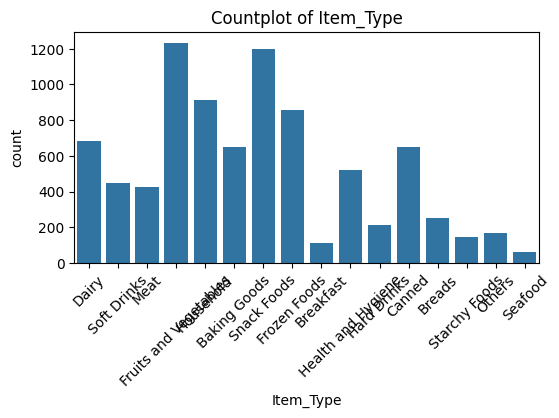

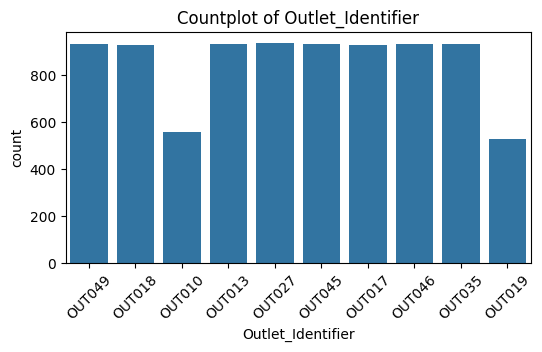

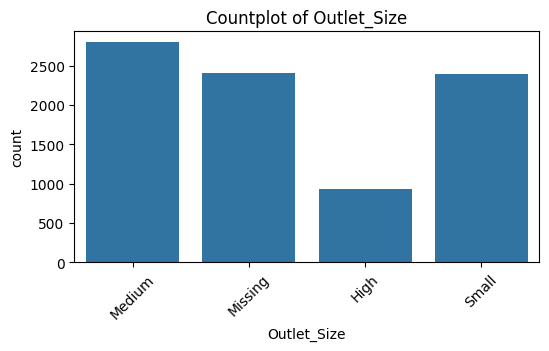

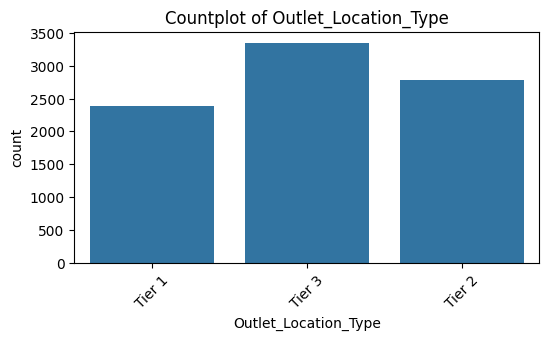

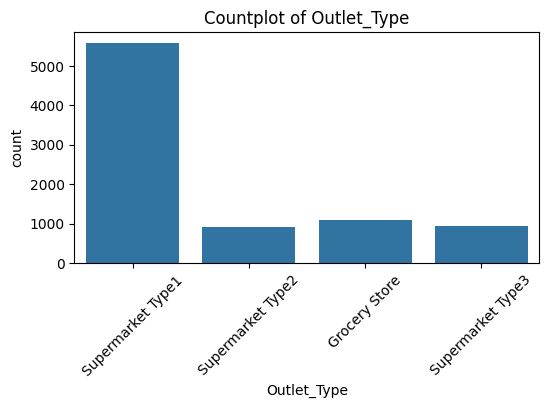

In [43]:
for c in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=c)
    plt.title(f'Countplot of {c}')
    plt.xticks(rotation=45)



```
# This is formatted as code
```

# Heatmap

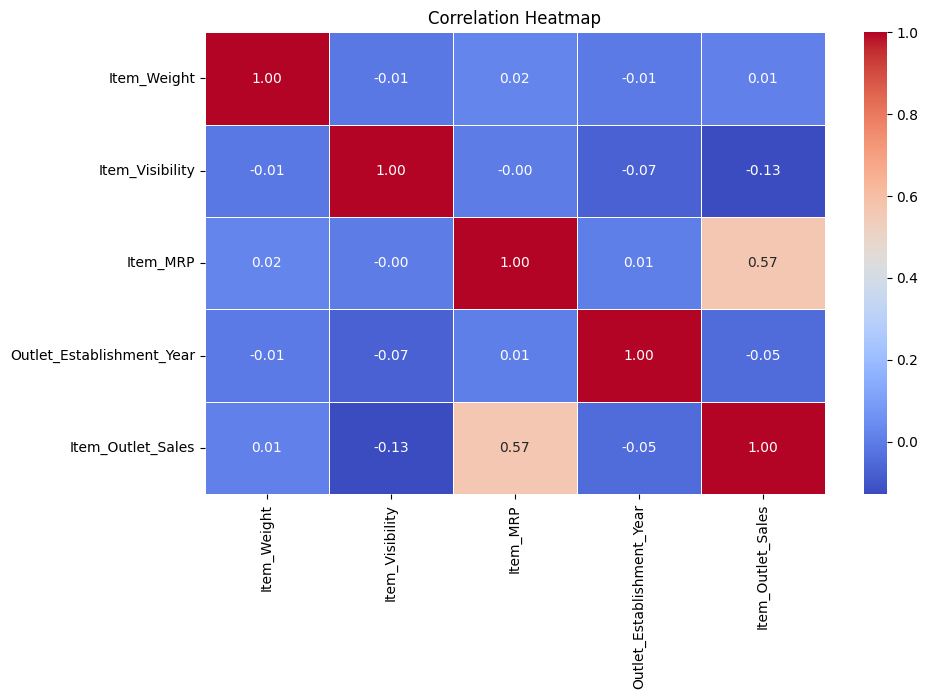

In [45]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Advance countplot

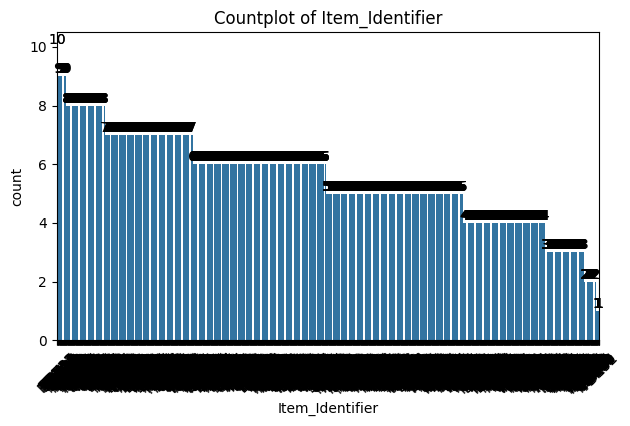

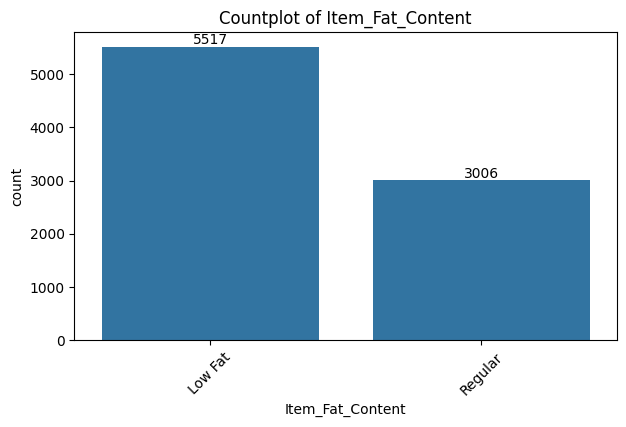

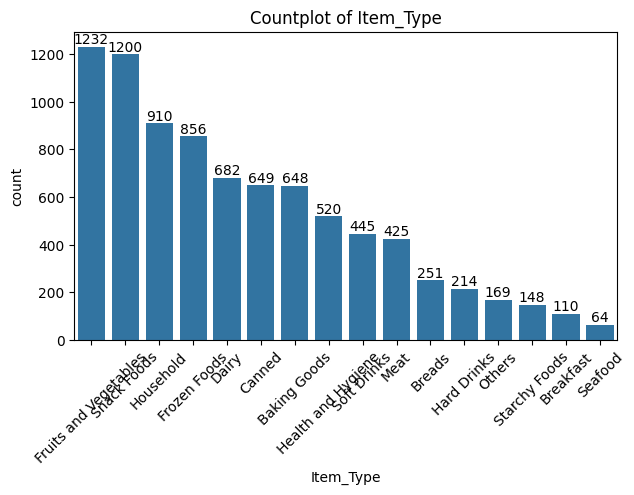

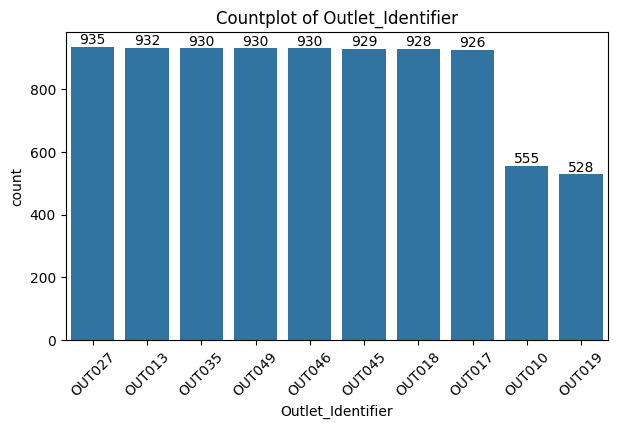

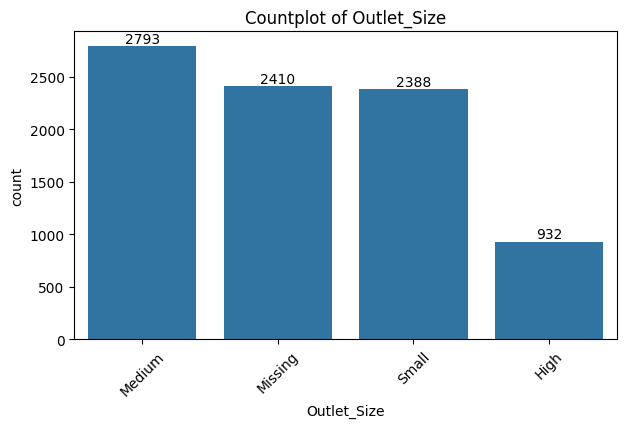

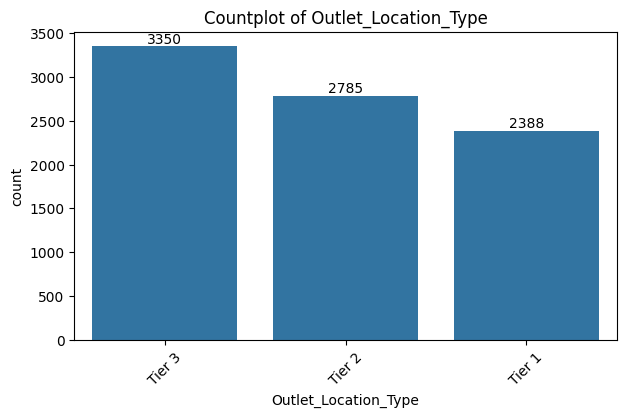

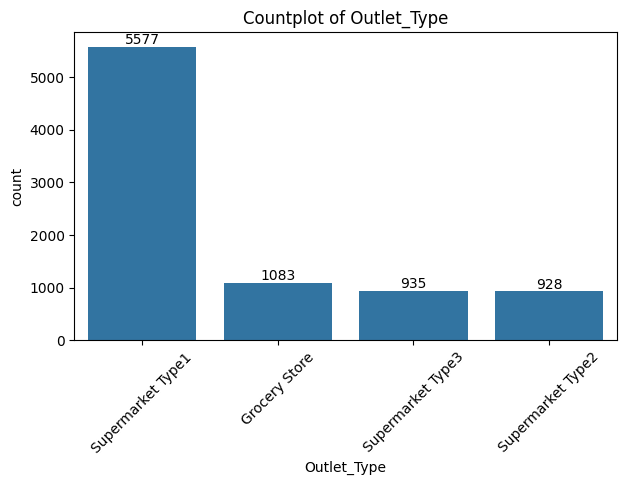

In [47]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')

    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()